# Retail customer segmentation (teaching notebook)

**Dataset:** `retail_customer_segmentation.csv` — one row per customer.

**Goal for this session:** load the data, explore it, then run a simple **K-Means** clustering on numeric + encoded categorical features. The column `customer_segment` is an *existing* business label you can compare against clusters (not used to train the unsupervised model).

Run cells **top to bottom** (Shift+Enter). Comments mark spots where the instructor can go deeper on theory.


## **Problem Statement**
Predict the customer_segment for each customer.

Target Classes
Occasional — Low engagement and transactional activity
Regular — Moderate purchasing consistency
Loyal — High engagement and repeat behavior
High_Value — Top-tier customers with strong lifetime value signals
The segmentation logic is behavior-driven and influenced by nonlinear feature interactions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from pathlib import Path

DATA_PATH = Path("retail_customer_segmentation.csv")

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()


,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  str    
 12  region                 50000 non-null  str    
 13  customer_segment       50000 non-null  str    
dtypes: float64(8), int64(3), str(3)
memory usage: 5.3 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,50000.0,25000.500000,14433.901067,1.000000,12500.750000,25000.500000,37500.250000,50000.000000
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,46925.0,44542.620904,30537.946035,2946.317892,24373.244554,36787.730010,55497.245522,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,47480.0,337.294238,204.627095,8.072298,192.074544,297.477404,439.112361,3026.342238
purchase_frequency,48021.0,4.910841,3.416115,0.017013,2.456867,4.158673,6.526903,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,47451.0,0.284358,0.159236,0.000534,0.160497,0.262591,0.387640,0.934655
return_rate,47513.0,0.148964,0.110508,0.000050,0.063938,0.123628,0.209612,0.830395
browsing_time_minutes,46066.0,61.781329,41.743394,0.236109,31.082283,52.679175,82.549571,406.813006


## 3. Missing values

Real retail-style data often has gaps. We summarize how many values are missing per column before deciding how to handle them (imputation vs dropping rows).


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) *100).round(2)
pd.DataFrame({"missing_count": missing, "missing_percentage": missing_pct}).sort_values(
    "missing_count", ascending=False
)

,missing_count,missing_percentage
browsing_time_minutes,3934,7.87
annual_income,3075,6.15
discount_usage_rate,2549,5.10
avg_monthly_spend,2520,5.04
return_rate,2487,4.97
support_interactions,1988,3.98
purchase_frequency,1979,3.96
months_active,0,0.00
customer_id,0,0.00
age,0,0.00


##  What missing_pct means
For each column, pandas counts how many cells are missing (true missing values: “empty” in CSV, parsed as NaN for numbers, or NaN/NaT in pandas). Then:

missing_pct = (missing_count / number of rows) × 100

So for example 7.87 on browsing_time_minutes means about 7.87% of all customers have no value in that column. Same idea for 6.15 on annual_income, etc. Columns with 0.00 have no missing values in the way pandas counts “missing.”

In [7]:
pattern = r"^\s*$|^nan$|^na$|^n/a$|^\?$|^none$|^null$|^unknown$"
object_cols = df.select_dtypes(include=["object", "string"]).columns
found_any =False

for col in object_cols:
    s = df[col].astype(str).str.strip().str.lower()
    mask = s.str.match(pattern, na=False)
    count = mask.sum()

    if count > 0:
        found_any = True
        print(f"Column '{col}' has {count} missing values matching the pattern.")
        display(df.loc[mask, [col]].head(10))
    else: 
        print(f"No suspicious string values found in column '{col}'.")
if not found_any:
    print("No suspicious string values found in any object columns.")

    

No suspicious string values found in column 'payment_method'.
No suspicious string values found in column 'region'.
No suspicious string values found in column 'customer_segment'.
No suspicious string values found in any object columns.


## What “normalized” means here
You take each text value, remove leading/trailing spaces (strip) and make everything lowercase (lower). That turns labels like "Urban" and " urban " into the same bucket so you can see if you accidentally have two versions of the same category.

payment_method
You see three clean buckets: card, upi, wallet. The counts (24,953 + 14,898 + 10,149) add up to your row count, so every customer has one of these three methods. If "Card" and "card" had both existed as separate raw strings, after normalization they would merge and you would see fewer than three rows in the normalized table (with larger counts on the merged label). Here you still have exactly three labels with stable totals — so no case/whitespace duplicates for payment method.

region
Raw labels are Urban, Semi-Urban, Rural. Normalized labels are urban, semi-urban, rural. The counts are identical to raw (24,785 / 15,212 / 10,003). So normalization only renamed for display; it did not merge any accidental duplicates. Same story: regions look consistent in the file.

customer_segment
Again, counts match before and after (Occasional → occasional, etc.). So you do not have two spellings like High_Value vs high_value as separate rows — one clean label per class.

One-line takeaway for students
Normalized counts are a duplicate detector. If raw and normalized tables show the same number of categories and the same counts (only lowercase), your categories are already clean; if counts jump when normalized (fewer rows), you had hidden duplicates to fix.



In [8]:
print("Nan")
display(df[object_cols].isna().sum())

Nan


payment_method      0
region              0
customer_segment    0
dtype: int64

In [ ]:

# =========================================================
# STEP 1: Focus on numeric columns that have missing values
# =========================================================

num_missing_cols = (
    df.select_dtypes(include=["number"])
      .columns[df.select_dtypes(include=["number"]).isna().sum() > 0]
      .tolist()
)
print("Numeric columns with missing values:")
print(num_missing_cols)

Numeric columns with missing values:
['annual_income', 'avg_monthly_spend', 'purchase_frequency', 'discount_usage_rate', 'return_rate', 'browsing_time_minutes', 'support_interactions']


In [ ]:
# =========================================================
# STEP 2: Check skewness (to guide imputation choice)
# Rule of thumb:
# - |skew| < 0.5  -> fairly symmetric
# - 0.5 to 1.0    -> moderately skewed
# - > 1.0         -> highly skewed
# =========================================================

skew_table = pd.DataFrame({
    "missing_count": df[num_missing_cols].isna().sum(),
    "skewness": df[num_missing_cols].skew(numeric_only=True).round(3), 
    "missing_pct": (df[num_missing_cols].isna().sum() / len(df) * 100).round(2)
}).sort_values("skewness", key=lambda s: s.abs(), ascending=False)

display(skew_table)

,missing_count,skewness,missing_pct
annual_income,3075,2.628,6.15
avg_monthly_spend,2520,1.752,5.04
purchase_frequency,1979,1.740,3.96
browsing_time_minutes,3934,1.350,7.87
return_rate,2487,1.122,4.97
support_interactions,1988,0.829,3.98
discount_usage_rate,2549,0.610,5.10


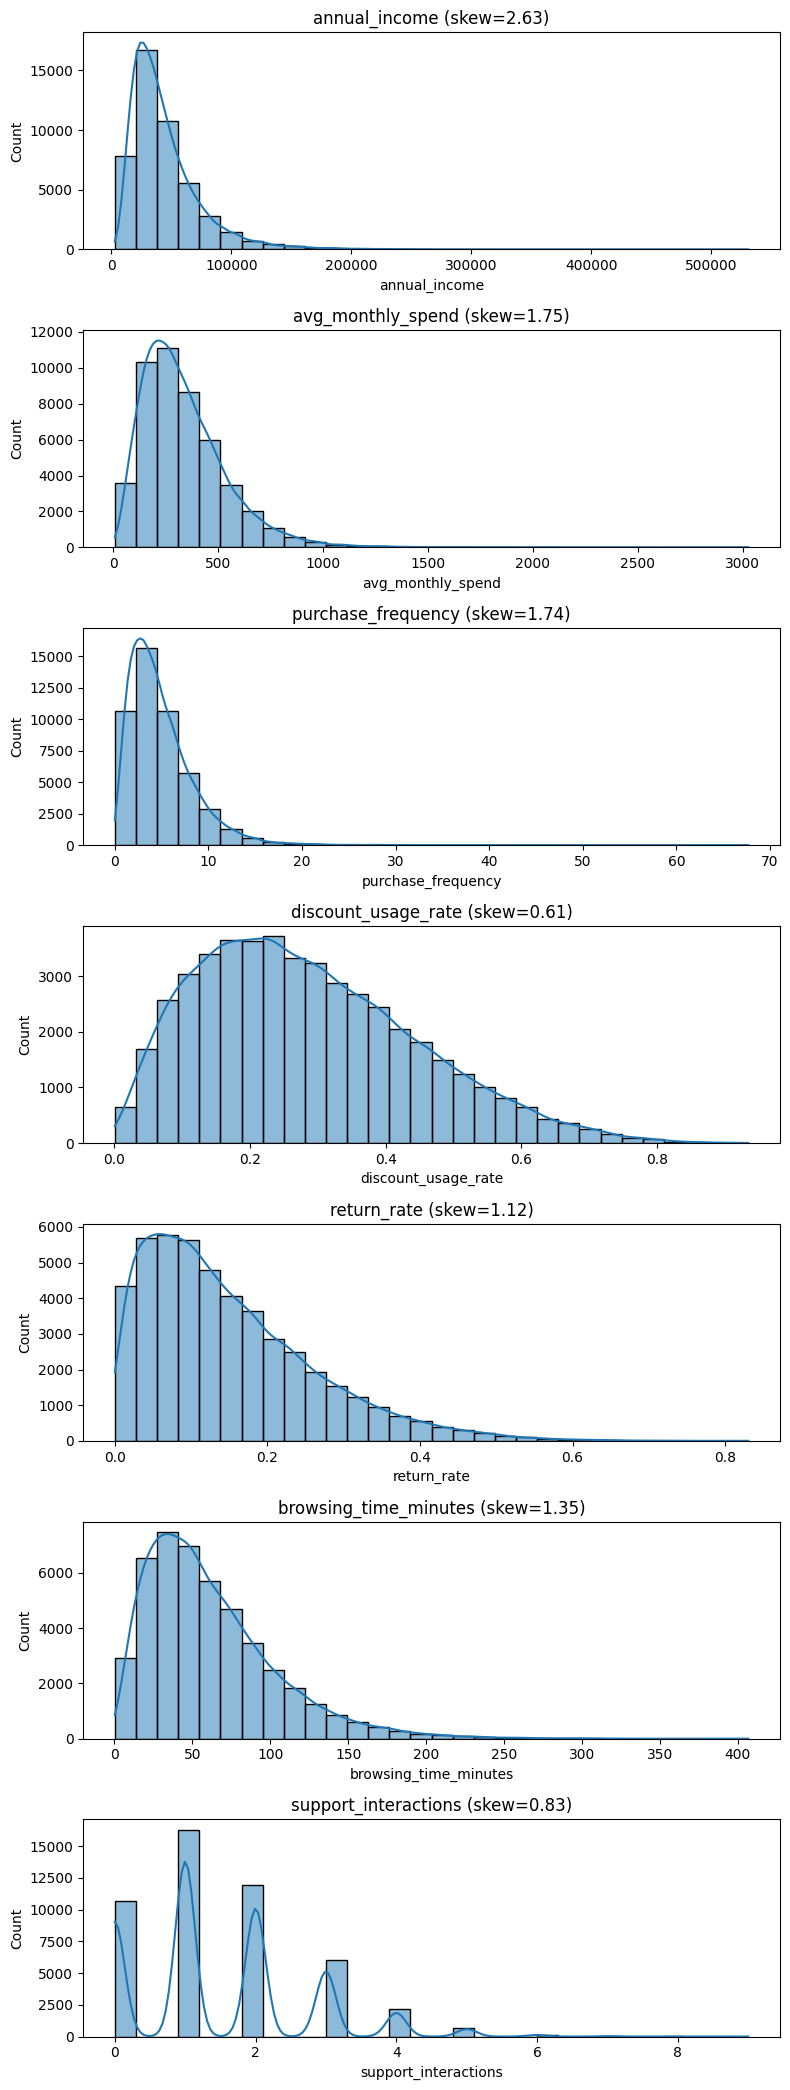

In [11]:
# =========================================================
# STEP 3 (optional but good for visualization):
# Visual check of distributions (non-missing values only)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

n = len(num_missing_cols)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 3*n))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, num_missing_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Check categorical levels (cleaned)
# ==========================================
categorical_cols = ["payment_method", "region", "customer_segment"]

for col in categorical_cols:
    print(f"\n--- {col}: raw counts ---")
    display(df[col].value_counts(dropna=False))
    
    print(f"--- {col}: normalized counts (strip + lower) ---")
    normalized = df[col].astype(str).str.strip().str.lower()
    display(normalized.value_counts(dropna=False))


--- payment_method: raw counts ---


payment_method
Card      24953
UPI       14898
Wallet    10149
Name: count, dtype: int64

--- payment_method: normalized counts (strip + lower) ---


payment_method
card      24953
upi       14898
wallet    10149
Name: count, dtype: int64


--- region: raw counts ---


...

region
urban         24785
semi-urban    15212
rural         10003
Name: count, dtype: int64


--- customer_segment: raw counts ---


customer_segment
Occasional    22109
Regular       13455
Loyal          9163
High_Value     5273
Name: count, dtype: int64

--- customer_segment: normalized counts (strip + lower) ---


customer_segment
occasional    22109
regular       13455
loyal          9163
high_value     5273
Name: count, dtype: int64

In [13]:
# =========================================================
# STEP 4: Build imputation strategy from skewness
# Teaching strategy:
# - If |skewness| >= 0.5 -> use MEDIAN (robust to skew/outliers)
# - Else                -> use MEAN
# =========================================================
impute_strategy = {
    col: ("median" if abs(df[col].skew()) >= 0.5 else "mean")
    for col in num_missing_cols
}

strategy_table = pd.DataFrame({
    "column": list(impute_strategy.keys()),
    "chosen_strategy": list(impute_strategy.values()),
    "skewness": [round(df[col].skew(), 3) for col in num_missing_cols]
}).sort_values("column")

display(strategy_table)

,column,chosen_strategy,skewness
0,annual_income,median,2.628
1,avg_monthly_spend,median,1.752
5,browsing_time_minutes,median,1.350
3,discount_usage_rate,median,0.610
2,purchase_frequency,median,1.740
4,return_rate,median,1.122
6,support_interactions,median,0.829


In [14]:
# =========================================================
# STEP 5: Apply numeric imputation based on chosen strategy
# Assumes categorical columns already normalized/cleaned by you
# =========================================================
df_clean = df.copy()

for col, strat in impute_strategy.items():
    if strat == "median":
        fill_value = df_clean[col].median()
    else:
        fill_value = df_clean[col].mean()
    df_clean[col] = df_clean[col].fillna(fill_value)

In [15]:
# =========================================================
# STEP 6: Verify missing values after imputation
# =========================================================
missing_after = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().sum() / len(df_clean) * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_after)
print("Total remaining missing values:", int(df_clean.isna().sum().sum()))

,missing_count,missing_pct
customer_id,0,0.0
age,0,0.0
annual_income,0,0.0
months_active,0,0.0
avg_monthly_spend,0,0.0
purchase_frequency,0,0.0
avg_order_value,0,0.0
discount_usage_rate,0,0.0
return_rate,0,0.0
browsing_time_minutes,0,0.0


Total remaining missing values: 0


### Exploratory Data Analysis (using `df_clean`)

After imputation, numeric columns used in modeling should have **no missing values**. This section summarizes distributions, the **target** (`customer_segment`), how segments relate to **region** and **payment_method**, and **correlations** among numeric features.

Run these cells **after** cleaning so every plot uses the same filled-in data.

In [16]:
# --- Column groups for EDA (keep in sync with features you use for modeling) ---
numeric_cols = [
    "age", "annual_income", "months_active", "avg_monthly_spend",
    "purchase_frequency", "avg_order_value", "discount_usage_rate",
    "return_rate", "browsing_time_minutes", "support_interactions",
]
categorical_cols = ["payment_method", "region"]
target_col = "customer_segment"

# Fail fast if someone runs EDA before imputation (avoids silent wrong plots)
assert df_clean.isna().sum().sum() == 0, (
    "df_clean still has missing values — finish cleaning first, or impute categoricals too."
)
print("EDA rows:", len(df_clean))

EDA rows: 50000


In [17]:
# describe(): count, mean, std, min, quartiles, max — useful for scale and outliers discussion
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,50000.0,44065.695114,29642.592692,2946.317892,25112.704208,36787.730010,53830.215138,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,50000.0,335.287469,199.593893,8.072298,197.220824,297.477404,429.191654,3026.342238
purchase_frequency,50000.0,4.881070,3.351036,0.017013,2.526421,4.158673,6.399534,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,50000.0,0.283248,0.155198,0.000534,0.166100,0.262591,0.380198,0.934655
return_rate,50000.0,0.147704,0.107865,0.000050,0.066834,0.123628,0.203893,0.830395
browsing_time_minutes,50000.0,61.065171,40.142412,0.236109,32.836514,52.679175,79.367471,406.813006
support_interactions,50000.0,1.474940,1.200650,0.000000,1.000000,1.000000,2.000000,9.000000


,count,percent
customer_segment,,
Occasional,22109,44.22
Regular,13455,26.91
Loyal,9163,18.33
High_Value,5273,10.55


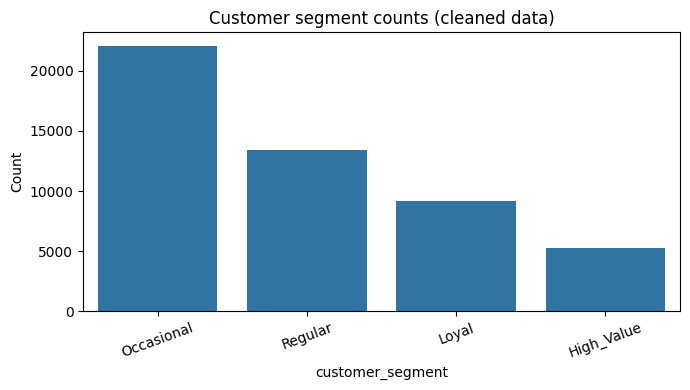

In [18]:
# Target: check class balance (affects accuracy vs precision/recall / F1 in classification)
counts = df_clean[target_col].value_counts()
pct = (counts / len(df_clean) * 100).round(2)
summary = pd.DataFrame({"count": counts, "percent": pct})
display(summary)

plt.figure(figsize=(7, 4))
sns.barplot(x=summary.index.astype(str), y=summary["count"], order=summary.index)
plt.title("Customer segment counts (cleaned data)")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Target distribution (table + bar chart)
What it shows
Roughly: Occasional (44%) > Regular (27%) > Loyal (18%) > High_Value (11%). The bar chart is the same story visually: one large class, one small class.

Meaning
This is class imbalance: the model will see many more “Occasional” rows than “High_Value” rows. Accuracy can look “good” even if the model mostly predicts the majority class.

Effect on analysis

For training/evaluation: use stratified train/validation/test splits so each split has similar class proportions.
Metrics: don’t rely only on accuracy; add macro/micro F1, per-class precision/recall, or a confusion matrix.
Training options (pick what fits your course): class_weight='balanced', resampling, or threshold tuning for minority classes.
Where you’re going
we are building a multiclass classifier for customer_segment; the imbalance shapes how you measure success, not just “did we hit 90% accuracy.”

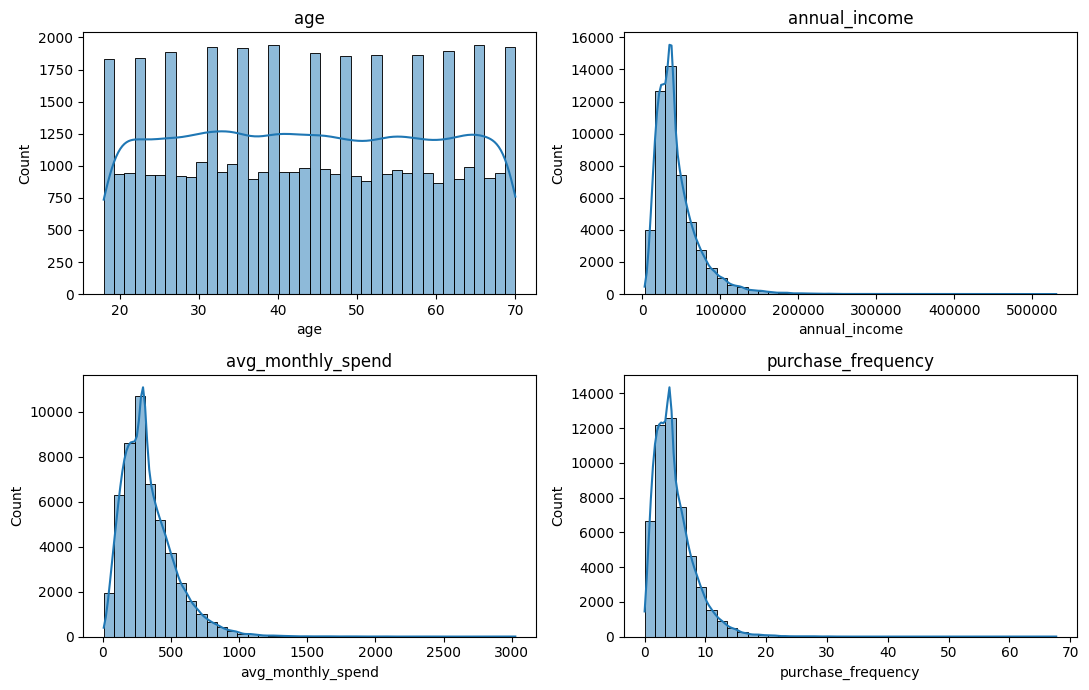

In [19]:
# Distributions after imputation: shapes may look smoother where many values were filled
plot_cols = ["age", "annual_income", "avg_monthly_spend", "purchase_frequency"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Histograms (age, income, spend, frequency)
What they show

Age looks fairly flat / even across the range (no strong skew in the plot you described). Mean and median will be similar; imputation choice matters less here.
Annual income, avg monthly spend, and purchase frequency are right-skewed: many moderate values, a long tail of high values.
Meaning
Skew and tails pull the mean upward; the median sits closer to “typical” customers. That supports using median imputation (or robust scalers) for those skewed columns.

Effect on analysis

Distance-based models (KNN, SVM with RBF) and neural nets benefit from scaling; trees are less sensitive but still use thresholds.
Linear correlations (next section) summarize straight-line relationships; skewed or nonlinear behavior may need bins, log transforms, or tree/ensemble models.
Where you’re going
These plots justify our preprocessing (median fill, scaling) and motivate nonlinear models if segments are driven by interactions

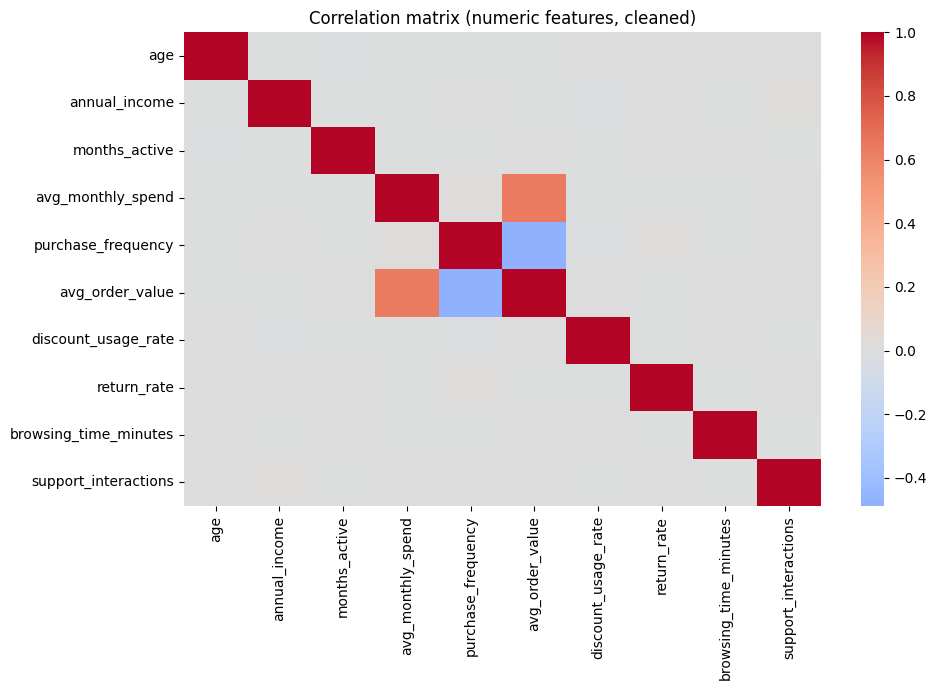

In [20]:
# Pearson correlation: linear association only (not causation; nonlinear links won't show well)
corr = df_clean[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix (numeric features, cleaned)")
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric features)
What it shows

Diagonal = 1 (each variable with itself): not informative, just definition.
Most cells are near zero (light): linear Pearson correlation between many pairs is weak.
Notable patterns from our description: positive association between avg_monthly_spend and avg_order_value; negative between purchase_frequency and avg_order_value (shop often vs. big basket, a classic tradeoff).
Meaning
Correlation is linear only. Weak heatmap cells do not mean “features are useless”; they can still separate segments through nonlinear or joint effects.

Effect on analysis

Mild multicollinearity among spend/frequency/order value is possible; trees handle it well; linear models may need regularization or dropping one of a redundant pair after checks.
Do not over-interpret the heatmap as “causality.”
Where you’re going
These variables are plausible drivers of segments in models that can capture interactions (trees, ensembles). The heatmap helps feature intuition, not the final decision boundary.

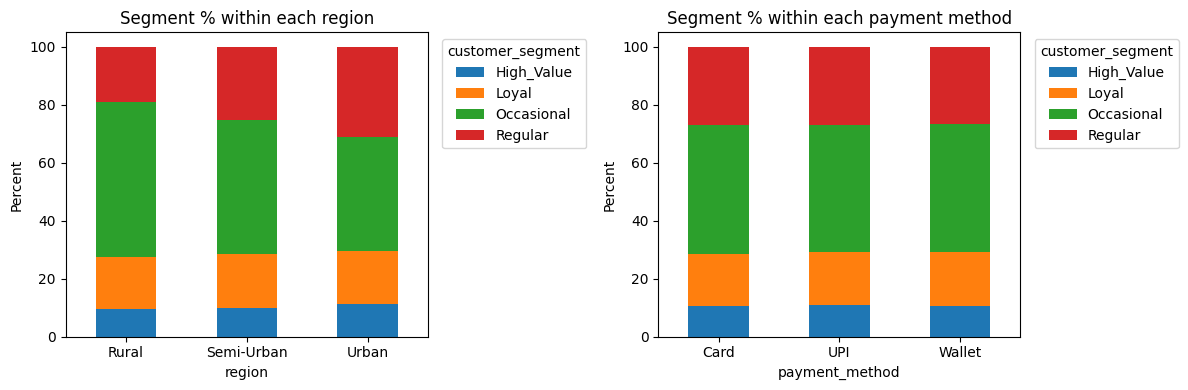

In [21]:
# Within each region / payment type: what % fall in each segment? (comparable across groups)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct_region = pd.crosstab(df_clean["region"], df_clean[target_col], normalize="index") * 100
ct_region.plot(kind="bar", stacked=True, ax=axes[0], rot=0)
axes[0].set_title("Segment % within each region")
axes[0].set_ylabel("Percent")
axes[0].legend(title=target_col, bbox_to_anchor=(1.02, 1), loc="upper left")

ct_pay = pd.crosstab(df_clean["payment_method"], df_clean[target_col], normalize="index") * 100
ct_pay.plot(kind="bar", stacked=True, ax=axes[1], rot=0)
axes[1].set_title("Segment % within each payment method")
axes[1].set_ylabel("Percent")
axes[1].legend(title=target_col, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Stacked bars: segment % within region and within payment method
What they shows

By region: proportions are similar across Rural / Semi-Urban / Urban (same four colors in roughly similar shares). Urban may show small shifts (e.g. slightly more High_Value/Loyal in some plots), but nothing dramatic.
By payment method: Card / UPI / Wallet bars look almost the same — segment mix is nearly identical across payment types.
Meaning
Region and payment_method alone do not strongly separate segments in a simple proportional sense. Segmentation in this dataset is likely driven more by behavioral numerics (spend, frequency, returns, discounts, browsing, etc.) than by these two categoricals alone.

Effect on analysis

Still include them in the model: they can add small gains or interactions (e.g. region × spend) even if marginal plots look flat.
Do not expect a decision tree’s first split to be only “Urban vs Rural”; learners may still use these after numeric thresholds.
Where you’re going
EDA says: do not over-trust geography or payment as standalone segment definitions; it pushes us toward multivariate models and feature importance after training.



In [22]:
from pathlib import Path

# Same folder as this notebook by default (change if you want a subfolder)
OUTPUT_PATH = Path("retail_customer_segmentation_cleaned.csv")

# index=False: do not write pandas row numbers as an extra column
df_clean.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH.resolve())
print("Rows, columns written:", df_clean.shape)

Saved: C:\Users\VICTUS\Documents\GITHUB\techcrush-practice\retail_customer_segmentation_cleaned.csv
Rows, columns written: (50000, 14)


In [24]:
!pip install scikit-learn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires tqdm, which is not installed.


In [27]:
!pip install -U scikit-learn

In [25]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

feature_numeric = [
    "age", "annual_income", "months_active", "avg_monthly_spend",
    "purchase_frequency", "avg_order_value", "discount_usage_rate",
    "return_rate", "browsing_time_minutes", "support_interactions",
]
feature_categorical = ["payment_method", "region"]

if "df_clean" not in globals():
    raise RuntimeError("Run the cleaning cells first to create df_clean.")

X = df_clean.drop(columns=["customer_id", "customer_segment"]).copy()
y_raw = df_clean["customer_segment"]

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

# Stratified: 60% train / 20% validation / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train / val / test sizes:", len(X_train), len(X_val), len(X_test))
print("Classes:", list(class_names))

Train / val / test sizes: 30000 10000 10000
Classes: ['High_Value', 'Loyal', 'Occasional', 'Regular']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

preprocess_sl = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_numeric),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            feature_categorical,
        ),
    ]
)

log_pipe = Pipeline(
    steps=[
        ("prep", preprocess_sl),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42,
            ),
        ),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("prep", preprocess_sl),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

print("Pipelines ready: logistic regression + random forest.")

Pipelines ready: logistic regression + random forest.


In [30]:
log_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

print(
    "Validation accuracy — logistic:",
    f"{log_pipe.score(X_val, y_val):.4f},",
    "random forest:",
    f"{rf_pipe.score(X_val, y_val):.4f}",
)

Validation accuracy — logistic: 0.6409, random forest: 0.7535


Logistic regression (baseline)
Accuracy (test): 0.6372

              precision    recall  f1-score   support

  High_Value       0.55      0.78      0.65      1055
       Loyal       0.58      0.67      0.63      1832
  Occasional       0.80      0.66      0.72      4422
     Regular       0.51      0.51      0.51      2691

    accuracy                           0.64     10000
   macro avg       0.61      0.66      0.63     10000
weighted avg       0.65      0.64      0.64     10000



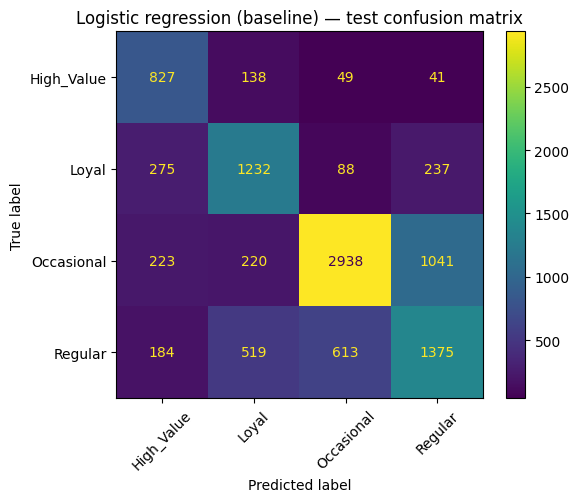

Random forest
Accuracy (test): 0.7539

              precision    recall  f1-score   support

  High_Value       0.84      0.79      0.81      1055
       Loyal       0.84      0.79      0.81      1832
  Occasional       0.76      0.85      0.80      4422
     Regular       0.65      0.56      0.60      2691

    accuracy                           0.75     10000
   macro avg       0.77      0.75      0.76     10000
weighted avg       0.75      0.75      0.75     10000



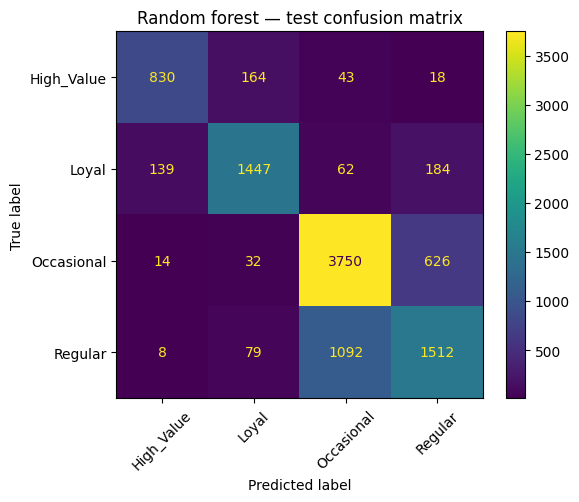

In [31]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

def report_model(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy (test): {accuracy_score(y_te, y_pred):.4f}\n")
    print(classification_report(y_te, y_pred, target_names=class_names))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_te,
        y_pred,
        display_labels=class_names,
        xticks_rotation=45,
        ax=ax,
    )
    ax.set_title(f"{name} — test confusion matrix")
    plt.tight_layout()
    plt.show()

report_model("Logistic regression (baseline)", log_pipe, X_test, y_test)
report_model("Random forest", rf_pipe, X_test, y_test)

# Overall Explanation
Test accuracy 0.754 vs ~0.637 for logistic regression — about 12 percentage points higher.
Weighted F1 ~0.75 vs ~0.64 — the forest is clearly stronger on this task, which matches what you already saw on validation (0.754 vs 0.641).
That pattern usually means nonlinear behavior and feature interactions (e.g. spend × frequency × discounts) matter for separating segments, and trees can approximate those boundaries better than a single linear decision surface.

Validation: logistic vs random forest
Logistic regression (validation): ~0.641
Random forest (validation): ~0.754
On the same validation set, the forest is much stronger, which usually means nonlinear relationships and interactions between features (spend × frequency × region, etc.) matter, and a linear model cannot bend enough to separate segments. You should still look at the random forest test report and confusion matrix — validation already suggests it should beat logistic on test as well.

Reading the classification report (logistic, test)
Precision = “When the model says this segment, how often is it right?”
Recall = “Of all true customers in this segment, how many did we catch?”

Class	Precision	Recall	Plain language
High_Value
0.55
0.78
The model finds most true High_Value customers (high recall), but when it predicts High_Value, it is often wrong (moderate precision → many false alarms).
Loyal
0.58
0.67
Moderate on both; some confusion with neighbors (e.g. Regular / High_Value).
Occasional
0.80
0.66
When it says Occasional, it is usually correct (high precision), but it misses a fair number of true Occasionals (lower recall).
Regular
0.51
0.51
Weakest class: both precision and recall near coin-flip level once you account for imbalance — the model struggles most here.
Macro avg (~0.61 / 0.66 / 0.63) treats each class equally — useful when no segment should be ignored.
Weighted avg (~0.65 / 0.64 / 0.64) follows dataset size — dominated by Occasional / Regular.

What the confusion matrix adds (logistic)
Occasional ↔ Regular is a major error pattern: many true Occasionals predicted as Regular and vice versa. That fits the story that those two are behaviorally similar on linear scores (middle engagement), so boundaries are fuzzy.
Regular → Loyal is also large (hundreds): the model mixes steady mid-tier behavior across those labels.
High_Value: good diagonal count, but Loyal → predicted High_Value (and similar) shows overlap between “very engaged” and “high value” in feature space.
So: the model is not random, but it blurs adjacent segments along the “value / engagement” spectrum.

Business angle (for  our discussion)
High recall, lower precision for High_Value (if that pattern holds): you flag most VIPs, but also elevate some non-VIPs — extra marketing cost or false “VIP” treatment unless you add probability thresholds or cost-sensitive decisions.
Occasional vs Regular confusion: wrong tier for campaigns that depend on exact label — consider ordering segments (e.g. treat as ordered categories) or probability outputs instead of a single hard label.
Where this leaves the lesson
Linear baseline (logistic) sets expectations: ~64% accuracy, clear Occasional/Regular confusion.
Random forest (validation ~0.75) suggests a stronger fit — show students the test metrics for RF next and compare confusion matrices side by side.
Emphasize per-class goals: e.g. maximize recall for High_Value vs precision, depending on business cost.


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

feature_numeric = [
    "age", "annual_income", "months_active", "avg_monthly_spend",
    "purchase_frequency", "avg_order_value", "discount_usage_rate",
    "return_rate", "browsing_time_minutes", "support_interactions",
]
feature_categorical = ["payment_method", "region"]

# Clustering inputs: no ID, no target
X_unsup = df_clean.drop(columns=["customer_id", "customer_segment"]).copy()

preprocess_unsup = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_numeric),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            feature_categorical,
        ),
    ]
)

X_scaled = preprocess_unsup.fit_transform(X_unsup)
print("Shape for clustering:", X_scaled.shape)

Shape for clustering: (50000, 16)


Why (50000, 16) and not 14 columns?
14 is the number of columns in the CSV (customer_id + 10 numerics + 2 categoricals + customer_segment).

For clustering you drop customer_id and customer_segment, so you start from 12 raw feature columns (10 numeric + payment_method + region).

After preprocessing, ColumnTransformer does not keep 12 columns:

10 numeric → 10 columns after StandardScaler (one per feature).
payment_method → one-hot: one column per category (e.g. Card, UPI, Wallet → 3 columns).
region → one-hot: e.g. Urban, Semi-Urban, Rural → 3 columns.
So:

10 + 3 + 3 = 16 engineered features.

That is expected: one-hot encoding expands categoricals into several binary columns. The “extra 2” are not mysterious extra raw columns — they are two of the six dummy columns from the two categorical fields (14 − 12 isn’t the right comparison; compare 12 raw inputs → 16 numeric columns after encoding).

In [33]:
from sklearn.cluster import KMeans

# k=4 matches four named segments for *comparison only* — try other k in class
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_km = kmeans.fit_predict(X_scaled)

df_unsup = df_clean.copy()
df_unsup["cluster_kmeans"] = labels_km

print("K-Means cluster sizes:")
print(df_unsup["cluster_kmeans"].value_counts().sort_index())

K-Means cluster sizes:
cluster_kmeans
0     8051
1    23526
2     8855
3     9568
Name: count, dtype: int64


# Silhouette ≈ 0.087 (K-Means, k = 4)
Silhouette is −1 to 1; values near 0 mean clusters overlap or are weakly separated. 0.087 says K-Means with k = 4 is not finding crisp, well-separated balls — which is normal for messy customer behavior and an arbitrary k.

# K-Means sizes and crosstab (short interpretation)
Cluster 1 is largest (23526) and mixes all four segments — behaves like a broad “average” bucket.
Cluster 2 has many Occasional (6955) but very few Loyal (166) — somewhat specialized compared to others.
Clusters 0 and 3 are more mixed across segments.
So K-Means is not reproducing customer_segment as four clean blocks; it’s carving space by distance on scaled + one-hot features, which need not match marketing labels. That’s exactly what you want students to see: unsupervised groups ≠ labeled segments, unless the labels were defined the same way as those distances.

In [34]:
# Rows = K-Means cluster, columns = business segment (not used in training)
pd.crosstab(df_unsup["cluster_kmeans"], df_unsup["customer_segment"], margins=True)

customer_segment,High_Value,Loyal,Occasional,Regular,All
cluster_kmeans,,,,,
0,903,1498,3019,2631,8051
1,2536,5506,8342,7142,23526
2,814,166,6955,920,8855
3,1020,1993,3793,2762,9568
All,5273,9163,22109,13455,50000


Your crosstab (K-Means cluster × customer_segment)
Rows = K-Means cluster ID (0–3). Columns = true business segment. Cells = counts of customers.

What it shows

No row is “pure” one segment. Every cluster mixes High_Value, Loyal, Occasional, Regular.
Cluster 1 (23 526 people) is the big middle: all four segments appear in large numbers — K-Means put many “average distance” customers together.
Cluster 2 is skewed: lots of Occasional (6955) vs very few Loyal (166) — that cluster captures a specific region of the feature space (e.g. certain spend/frequency patterns), not one marketing label.
Clusters 0 and 3 are mixed but not identical to 1 and 2 — different centroids, different mixes.
Interpretation for class

K-Means did not recover the four marketing labels as four separate boxes. It found four groups by Euclidean distance on scaled + one-hot features.
The crosstab is a diagnostic: “If we forced four clusters, how do they line up with our labels?” Partial overlap is normal.
How K-Means really works (and what “result” it gives)
Goal: Split points into 
k
k groups so that points in a group are close to that group’s centroid (mean), and far from other centroids — measured by sum of squared distances (inertia / WCSS).

Algorithm (simplified)

Place 
k
k centroids (often random).
Assign each point to the nearest centroid (by Euclidean distance in your feature space).
Recompute each centroid as the mean of its points.
Repeat 2–3 until assignments barely change.
What you get out

A cluster label per customer (0 … k−1).
Centroids in feature space: the “typical” profile of each cluster (you can inverse-transform or describe in words for teaching).
Inertia (within-cluster sum of squares): lower means tighter clusters (but always compare with 
k
k — more clusters can always reduce inertia).
What K-Means does not give

It does not optimize accuracy vs customer_segment.
It does not guarantee “natural” segments in a business sense — only geometric blobs (and it prefers roundish, similar-variance clusters).
Direction for your teaching

Direction 1 — Exploratory: “Here are four behavioral bundles; let’s profile each cluster (mean spend, region mix, etc.).”
Direction 2 — Compare to labels: Crosstab shows alignment; mismatch means labels encode something else (rules, churn, margins) not identical to distance in these 16 features.
Direction 3 — Choose 
k
k: Try other 
k
k and compare silhouette, elbow, or business readability.
That is the honest story: silhouette = geometric separation quality; crosstab = overlap with business segments; K-Means = distance-based grouping, useful for discovery and discussion, not a drop-in replacement for your labeled customer_segment unless you design features and k, k to match that definition.

In [35]:
from sklearn.metrics import silhouette_score

# Silhouette uses distances — on huge n it is slow; subsample for class
rng = np.random.default_rng(42)
idx = rng.choice(len(X_scaled), size=min(8000, len(X_scaled)), replace=False)
sil = silhouette_score(X_scaled[idx], labels_km[idx])
print(f"Silhouette score (subsample, k={k}): {sil:.3f}")

Silhouette score (subsample, k=4): 0.087


In [36]:
from sklearn.cluster import DBSCAN

# Demo subsample so the cell finishes in reasonable time (raise n_sample cautiously)
n_sample = 12_000
idx_db = np.random.default_rng(42).choice(len(X_scaled), size=n_sample, replace=False)
X_db = X_scaled[idx_db]

# Start here and adjust: larger eps -> fewer noise points, merges clusters
db = DBSCAN(eps=1.2, min_samples=25, n_jobs=-1)
labels_db = db.fit_predict(X_db)

print("DBSCAN label counts (on subsample):")
print(pd.Series(labels_db).value_counts(dropna=False).sort_index())
noise_pct = (labels_db == -1).mean() * 100
print(f"Noise (-1): {noise_pct:.1f}% of subsample")

DBSCAN label counts (on subsample):
-1    12000
Name: count, dtype: int64
Noise (-1): 100.0% of subsample


DBSCAN: 100% noise (-1 only)
That means no point satisfied DBSCAN’s “core point” rule with your eps and min_samples on this 16-dimensional scaled matrix. In practice, in high dimensions neighbors are farther apart in Euclidean distance, so the same eps that works in 2D is often too small in 16D — everything looks isolated → all noise.

What to try (conceptually):

Increase eps a lot (e.g. try 2, 3, 4, 5, … on the same subsample) until you see non‑-1 labels, then refine.
Lower min_samples (e.g. 5–15) so core points are easier to form.
Optional for teaching: run DBSCAN on PCA (e.g. 5–10 components) or only numeric columns first so distance behavior is less extreme — many courses do this when demonstrating DBSCAN.
So your result is not “DBSCAN failed on the data” — it usually means parameters (and/or dimensionality) are mismatched to the default intuition from low-D examples.

In [37]:
# Compare cluster labels to segments only for the same rows as the subsample
pd.crosstab(
    pd.Series(labels_db, name="cluster_dbscan"),
    df_unsup["customer_segment"].iloc[idx_db].reset_index(drop=True),
    margins=True,
)

customer_segment,High_Value,Loyal,Occasional,Regular,All
cluster_dbscan,,,,,
-1,1246,2182,5370,3202,12000
All,1246,2182,5370,3202,12000
